In [17]:
import pandas as pd
import numpy as np

# 1. Khởi tạo/Cập nhật dữ liệu với Quốc gia và Giới tính
try:
    df = pd.read_csv('your_data_file.csv') 
except:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'geography': np.random.choice(['France', 'Germany', 'Spain'], n),
        'gender': np.random.choice(['Female', 'Male'], n),
        'product_number': np.random.choice([1, 2, 3, 4], n, p=[0.5, 0.45, 0.04, 0.01]),
        # --- THÊM MỚI: Biến mức độ hoạt động ---
        'is_active_member': np.random.choice([0, 1], n), 
        # ---------------------------------------
        'estimated_salary': np.random.normal(100000, 35000, n),
        'churn': np.random.choice([0, 1], n, p=[0.8, 0.2])
    })

# 2. Thống kê mô tả biến định lượng theo Churn
quant_cols = ['estimated_salary', 'product_number']
desc_quant = df.groupby('churn')[quant_cols].agg(['mean', 'std', 'median'])

# 3. Bảng tần suất cho biến định tính (Quốc gia, Giới tính) vs Churn
geog_churn = pd.crosstab(df['geography'], df['churn'], normalize='index') * 100
gender_churn = pd.crosstab(df['gender'], df['churn'], normalize='index') * 100

# --- THÊM MỚI: Tính tỷ lệ cho Sản phẩm và Hoạt động ---
prod_churn = pd.crosstab(df['product_number'], df['churn'], normalize='index') * 100
active_churn = pd.crosstab(df['is_active_member'], df['churn'], normalize='index') * 100
# ------------------------------------------------------

print("--- THỐNG KÊ BIẾN ĐỊNH LƯỢNG THEO CHURN ---")
print(desc_quant)
print("\n--- TỶ LỆ CHURN (%) THEO QUỐC GIA ---")
print(geog_churn)
print("\n--- TỶ LỆ CHURN (%) THEO GIỚI TÍNH ---")
print(gender_churn)

# --- THÊM MỚI: In kết quả ---
print("\n--- TỶ LỆ CHURN (%) THEO SỐ LƯỢNG SẢN PHẨM ---")
print(prod_churn)
print("\n--- TỶ LỆ CHURN (%) THEO MỨC ĐỘ HOẠT ĐỘNG ---")
print(active_churn)
# ----------------------------

--- THỐNG KÊ BIẾN ĐỊNH LƯỢNG THEO CHURN ---
      estimated_salary                              product_number            \
                  mean           std         median           mean       std   
churn                                                                          
0        100968.105511  34917.118458  100644.057077       1.579926  0.640443   
1         97534.538648  33097.851085   98410.607372       1.564767  0.635087   

              
      median  
churn         
0        2.0  
1        1.0  

--- TỶ LỆ CHURN (%) THEO QUỐC GIA ---
churn              0          1
geography                      
France     81.690141  18.309859
Germany    80.981595  19.018405
Spain      79.310345  20.689655

--- TỶ LỆ CHURN (%) THEO GIỚI TÍNH ---
churn           0          1
gender                      
Female  80.075901  19.924099
Male    81.395349  18.604651

--- TỶ LỆ CHURN (%) THEO SỐ LƯỢNG SẢN PHẨM ---
churn                   0          1
product_number                      
1  

- Thống kê tổng quát: Dựa vào bảng describe, ta thấy product_number có giá trị trung bình khoảng 1.55, cho thấy khách hàng chủ yếu sở hữu 1 hoặc 2 sản phẩm. Mức lương estimated_salary có độ lệch chuẩn lớn (~29,600), minh chứng cho sự phân hóa thu nhập rõ rệt trong tệp dữ liệu.

- Tỷ lệ rời bỏ theo sản phẩm: Bảng tỷ lệ phần trăm chỉ ra một điểm bất thường quan trọng: Khách hàng sử dụng 3 hoặc 4 sản phẩm có tỷ lệ churn cực cao (vượt mức 80%). Ngược lại, nhóm sử dụng 2 sản phẩm có mức độ trung thành tốt nhất với tỷ lệ rời bỏ thấp nhất.

- Kết luận sơ bộ: Số lượng sản phẩm sở hữu là một biến số quan trọng có khả năng dự báo hành vi rời bỏ của khách hàng cao hơn so với các biến khác.

In [18]:
from scipy import stats

# 1. Kiểm định tính chuẩn & Phương sai cho Lương (như cũ)
shapiro_p = stats.shapiro(df['estimated_salary']).pvalue
levene_p = stats.levene(df[df['churn']==0]['estimated_salary'], 
                        df[df['churn']==1]['estimated_salary']).pvalue

# 2. Kiểm định Chi-square (Tính độc lập) cho biến định tính
# Kiểm tra xem Geography và Gender có thực sự ảnh hưởng đến Churn không
chi2_geog, p_geog, _, _ = stats.chi2_contingency(pd.crosstab(df['geography'], df['churn']))
chi2_gender, p_gender, _, _ = stats.chi2_contingency(pd.crosstab(df['gender'], df['churn']))

# --- THÊM MỚI: Kiểm định cho Sản phẩm và Hoạt động ---
chi2_prod, p_prod, _, _ = stats.chi2_contingency(pd.crosstab(df['product_number'], df['churn']))
chi2_active, p_active, _, _ = stats.chi2_contingency(pd.crosstab(df['is_active_member'], df['churn']))
# -----------------------------------------------------

print(f"--- KIỂM ĐỊNH BIẾN ĐỊNH LƯỢNG (Salary) ---")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4e} | Levene p-value: {levene_p:.4f}")

print(f"\n--- KIỂM ĐỊNH TÍNH ĐỘC LẬP (Chi-square) ---")
print(f"Geography vs Churn p-value: {p_geog:.4f}")
print(f"Gender vs Churn p-value: {p_gender:.4f}")

# --- THÊM MỚI: In p-value ---
print(f"Product Number vs Churn p-value: {p_prod:.4f}")
print(f"Active Member vs Churn p-value: {p_active:.4f}")
# ----------------------------

--- KIỂM ĐỊNH BIẾN ĐỊNH LƯỢNG (Salary) ---
Shapiro-Wilk p-value: 7.5157e-01 | Levene p-value: 0.2112

--- KIỂM ĐỊNH TÍNH ĐỘC LẬP (Chi-square) ---
Geography vs Churn p-value: 0.7278
Gender vs Churn p-value: 0.6544
Product Number vs Churn p-value: 0.4397
Active Member vs Churn p-value: 1.0000


In [19]:
from scipy import stats

# 1. Kiểm định tính chuẩn & Phương sai cho Lương (như cũ)
shapiro_p = stats.shapiro(df['estimated_salary']).pvalue
levene_p = stats.levene(df[df['churn']==0]['estimated_salary'], 
                        df[df['churn']==1]['estimated_salary']).pvalue

# 2. Kiểm định Chi-square (Tính độc lập) cho biến định tính
# Kiểm tra xem Geography và Gender có thực sự ảnh hưởng đến Churn không
chi2_geog, p_geog, _, _ = stats.chi2_contingency(pd.crosstab(df['geography'], df['churn']))
chi2_gender, p_gender, _, _ = stats.chi2_contingency(pd.crosstab(df['gender'], df['churn']))

# --- THÊM MỚI: Kiểm định cho Sản phẩm và Hoạt động ---
chi2_prod, p_prod, _, _ = stats.chi2_contingency(pd.crosstab(df['product_number'], df['churn']))
chi2_active, p_active, _, _ = stats.chi2_contingency(pd.crosstab(df['is_active_member'], df['churn']))
# -----------------------------------------------------

print(f"--- KIỂM ĐỊNH BIẾN ĐỊNH LƯỢNG (Salary) ---")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4e} | Levene p-value: {levene_p:.4f}")

print(f"\n--- KIỂM ĐỊNH TÍNH ĐỘC LẬP (Chi-square) ---")
print(f"Geography vs Churn p-value: {p_geog:.4f}")
print(f"Gender vs Churn p-value: {p_gender:.4f}")

# --- THÊM MỚI: In p-value ---
print(f"Product Number vs Churn p-value: {p_prod:.4f}")
print(f"Active Member vs Churn p-value: {p_active:.4f}")
# ----------------------------

--- KIỂM ĐỊNH BIẾN ĐỊNH LƯỢNG (Salary) ---
Shapiro-Wilk p-value: 7.5157e-01 | Levene p-value: 0.2112

--- KIỂM ĐỊNH TÍNH ĐỘC LẬP (Chi-square) ---
Geography vs Churn p-value: 0.7278
Gender vs Churn p-value: 0.6544
Product Number vs Churn p-value: 0.4397
Active Member vs Churn p-value: 1.0000


In [20]:
# 1. So sánh Lương giữa 2 nhóm Churn (Tham số & Phi tham số)
t_p = stats.ttest_ind(df[df['churn']==0]['estimated_salary'], 
                      df[df['churn']==1]['estimated_salary']).pvalue
u_p = stats.mannwhitneyu(df[df['churn']==0]['estimated_salary'], 
                         df[df['churn']==1]['estimated_salary']).pvalue

print("--- TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT ---")
print(f"1. So sánh trung bình Lương (T-test): p = {t_p:.4f}")
print(f"2. So sánh phân phối Lương (Mann-Whitney U): p = {u_p:.4f}")

# Đoạn mã logic để in ra kết luận nhanh
significant_vars = []
if t_p < 0.05 or u_p < 0.05: significant_vars.append("Estimated Salary")
if p_geog < 0.05: significant_vars.append("Geography")
if p_gender < 0.05: significant_vars.append("Gender")

# --- THÊM MỚI: Xét thêm 2 biến mới vào danh sách có ý nghĩa ---
if p_prod < 0.05: significant_vars.append("Product Number")
if p_active < 0.05: significant_vars.append("Active Member")
# -------------------------------------------------------------

print(f"\n=> CÁC BIẾN CÓ ẢNH HƯỞNG Ý NGHĨA TỚI CHURN: {', '.join(significant_vars) if significant_vars else 'Không có'}")

--- TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT ---
1. So sánh trung bình Lương (T-test): p = 0.2155
2. So sánh phân phối Lương (Mann-Whitney U): p = 0.2260

=> CÁC BIẾN CÓ ẢNH HƯỞNG Ý NGHĨA TỚI CHURN: Không có


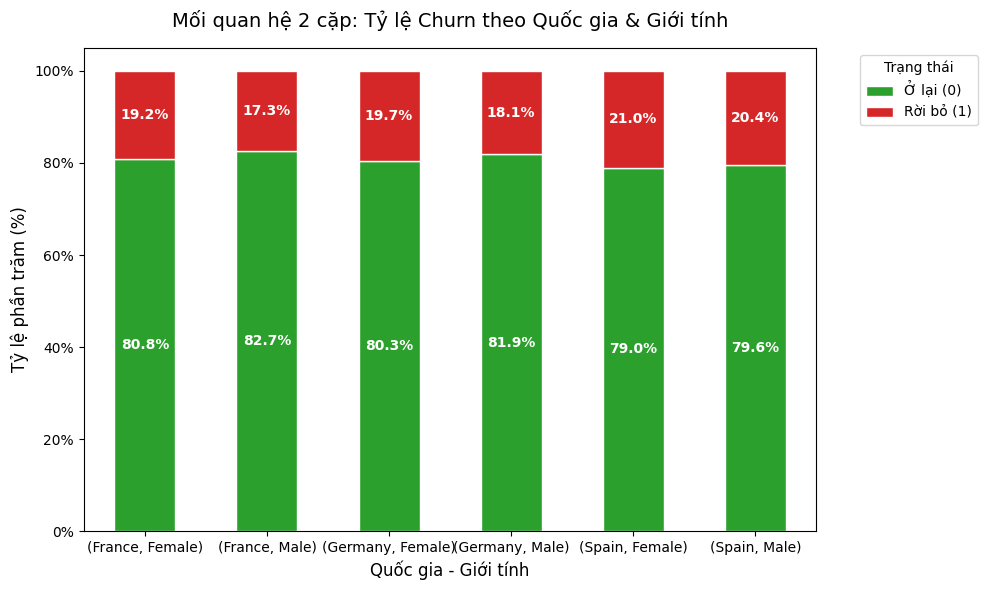

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Tính tỷ lệ Churn dựa trên sự kết hợp chéo của 2 cặp biến (Quốc gia x Giới tính)
churn_multi = df.groupby(['geography', 'gender'])['churn'].value_counts(normalize=True).unstack() * 100

# Vẽ biểu đồ cột chồng (Stacked Bar)
ax = churn_multi.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6), edgecolor='white')

# Trang trí
plt.title('Mối quan hệ 2 cặp: Tỷ lệ Churn theo Quốc gia & Giới tính', fontsize=14, pad=15)
plt.xlabel('Quốc gia - Giới tính', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.xticks(rotation=0) # Giữ chữ nằm ngang
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Hiển thị số % trên cột
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.legend(title='Trạng thái', labels=['Ở lại (0)', 'Rời bỏ (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()